In [ ]:
!pip install librosa scikit-learn numpy matplotlib seaborn joblib tqdm pandas -q

import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from pathlib import Path
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ZIP_PATH = '/content/drive/MyDrive/keystroke_clean.zip'
EXTRACT_DIR = '/content/dataset'

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting zip file...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done!")

Extracting zip file...
Done!


In [ ]:
TRAIN_DIR = Path('/content/dataset/keystroke_clean/data_raw/Train/Train')
VALID_DIR = Path('/content/dataset/keystroke_clean/data_raw/Valid/Valid')
TEST_DIR  = Path('/content/dataset/keystroke_clean/data_raw/Test/Test')

print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VALID_DIR exists:", VALID_DIR.exists())
print("TEST_DIR exists :", TEST_DIR.exists())

TRAIN_DIR exists: True
VALID_DIR exists: True
TEST_DIR exists : True


In [ ]:
def inspect_csv(split_dir, split_name):
    csv_path = split_dir / 'labels.csv'
    audio_dir = split_dir / 'audio_data'

    print(f"\n===== {split_name} =====")
    print("CSV exists   :", csv_path.exists())
    print("Audio exists :", audio_dir.exists())

    df = pd.read_csv(csv_path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head())

    return df

train_df = inspect_csv(TRAIN_DIR, 'TRAIN')
valid_df = inspect_csv(VALID_DIR, 'VALID')
test_df  = inspect_csv(TEST_DIR,  'TEST')


===== TRAIN =====
CSV exists   : True
Audio exists : True
Shape: (5120, 5)
Columns: ['filename', 'key', 'original_path', 'duration_s', 'segment_id']
    filename key original_path  duration_s segment_id
0   a_10.wav   a    a/a_10.wav        0.38       a_10
1  a_103.wav   a   a/a_103.wav        0.38      a_103
2  a_110.wav   a   a/a_110.wav        0.38      a_110
3  a_113.wav   a   a/a_113.wav        0.38      a_113
4  a_127.wav   a   a/a_127.wav        0.38      a_127

===== VALID =====
CSV exists   : True
Audio exists : True
Shape: (1280, 5)
Columns: ['filename', 'key', 'original_path', 'duration_s', 'segment_id']
    filename key original_path  duration_s segment_id
0  a_104.wav   a   a/a_104.wav        0.38      a_104
1  a_139.wav   a   a/a_139.wav        0.38      a_139
2   a_14.wav   a    a/a_14.wav        0.38       a_14
3  a_142.wav   a   a/a_142.wav        0.38      a_142
4  a_164.wav   a   a/a_164.wav        0.38      a_164

===== TEST =====
CSV exists   : True
Audio exists :

In [ ]:
def build_split_dataframe(df, split_dir):
    audio_dir = split_dir / 'audio_data'

    out = df.copy()
    out['filepath'] = out['filename'].apply(lambda x: str(audio_dir / x))
    out['exists'] = out['filepath'].apply(os.path.exists)

    missing = out[~out['exists']]
    if len(missing) > 0:
        print(f"Missing files in {split_dir}: {len(missing)}")
        print(missing.head())

    out = out[out['exists']].reset_index(drop=True)
    return out

train_meta = build_split_dataframe(train_df, TRAIN_DIR)
valid_meta = build_split_dataframe(valid_df, VALID_DIR)
test_meta  = build_split_dataframe(test_df, TEST_DIR)

print("Train shape:", train_meta.shape)
print("Valid shape:", valid_meta.shape)
print("Test shape :", test_meta.shape)

print("\nClasses:", sorted(train_meta['key'].unique()))
print("Number of classes:", train_meta['key'].nunique())

Train shape: (5120, 7)
Valid shape: (1280, 7)
Test shape : (1600, 7)

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 'space', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 27


In [ ]:
SAMPLE_RATE = 22050
DURATION = 0.40
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = 256

def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

        target_len = int(SAMPLE_RATE * DURATION)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)

        feat = np.concatenate([mfcc_mean, mfcc_std]).astype(np.float32)
        return feat

    except Exception as e:
        print(f"ERROR in {file_path}: {e}")
        return None

In [ ]:
sample_path = train_meta.loc[0, 'filepath']
sample_label = train_meta.loc[0, 'key']

print("Sample path :", sample_path)
print("Sample label:", sample_label)

sample_feat = extract_mfcc(sample_path)
print("Feature shape:", sample_feat.shape)
print("First 10 feature values:", sample_feat[:10])

Sample path : /content/dataset/keystroke_clean/data_raw/Train/Train/audio_data/a_10.wav
Sample label: a
Feature shape: (80,)
First 10 feature values: [-601.6229      98.84802      1.7055196   29.435547     5.4985685
   23.1717       6.2181883   17.129196     3.1511636    8.694712 ]


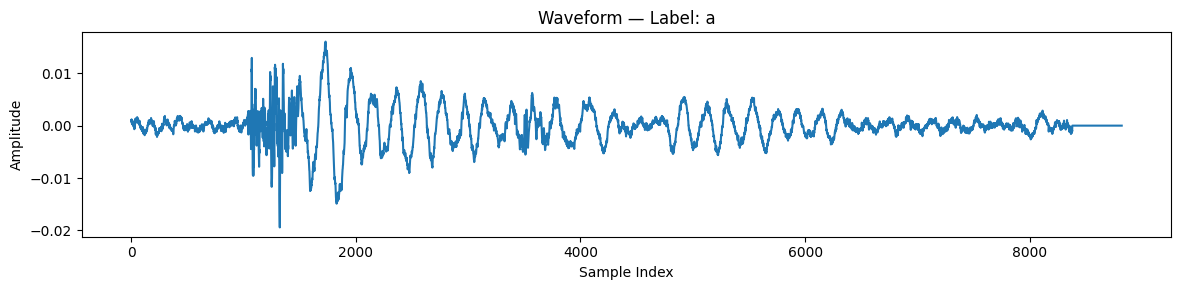

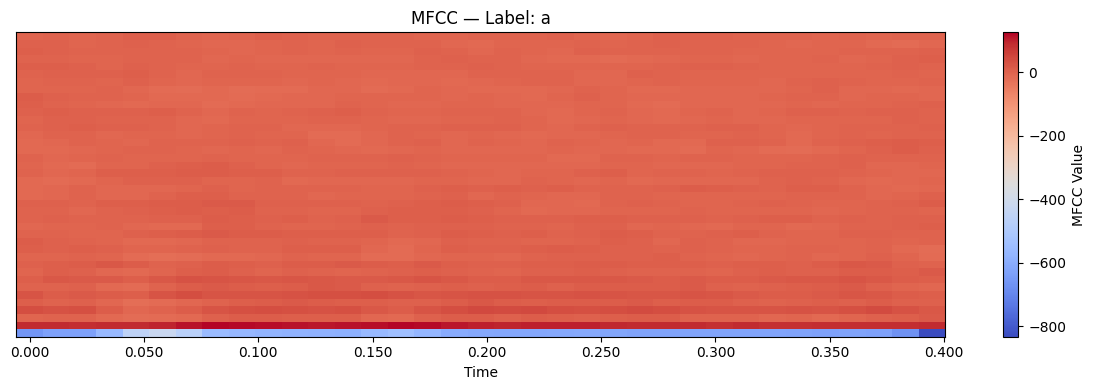

In [ ]:
y_audio, sr = librosa.load(sample_path, sr=SAMPLE_RATE, mono=True)

target_len = int(SAMPLE_RATE * DURATION)
if len(y_audio) < target_len:
    y_audio = np.pad(y_audio, (0, target_len - len(y_audio)))
else:
    y_audio = y_audio[:target_len]

plt.figure(figsize=(12, 3))
plt.plot(y_audio)
plt.title(f"Waveform — Label: {sample_label}")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

mfcc_vis = librosa.feature.mfcc(
    y=y_audio,
    sr=sr,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(
    mfcc_vis,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time'
)
plt.colorbar(img, label='MFCC Value')
plt.title(f"MFCC — Label: {sample_label}")
plt.tight_layout()
plt.show()

In [ ]:
def build_features(meta_df, split_name):
    X_list = []
    y_list = []

    print(f"Extracting {split_name} features from {len(meta_df)} files...")

    for _, row in tqdm(meta_df.iterrows(), total=len(meta_df), desc=split_name):
        feat = extract_mfcc(row['filepath'])
        if feat is not None:
            X_list.append(feat)
            y_list.append(row['key'])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)

    print(f"{split_name} X shape: {X.shape}")
    print(f"{split_name} y shape: {y.shape}")

    return X, y

X_train, y_train_raw = build_features(train_meta, 'TRAIN')
X_valid, y_valid_raw = build_features(valid_meta, 'VALID')
X_test,  y_test_raw  = build_features(test_meta, 'TEST')

Extracting TRAIN features from 5120 files...


TRAIN: 100%|██████████| 5120/5120 [00:47<00:00, 107.49it/s]


TRAIN X shape: (5120, 80)
TRAIN y shape: (5120,)
Extracting VALID features from 1280 files...


VALID: 100%|██████████| 1280/1280 [00:12<00:00, 99.73it/s] 


VALID X shape: (1280, 80)
VALID y shape: (1280,)
Extracting TEST features from 1600 files...


TEST: 100%|██████████| 1600/1600 [00:15<00:00, 102.11it/s]

TEST X shape: (1600, 80)
TEST y shape: (1600,)


In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train_raw)
y_valid = le.transform(y_valid_raw)
y_test  = le.transform(y_test_raw)

print("Classes:", list(le.classes_))
print("Number of classes:", len(le.classes_))

Classes: [np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('space'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]
Number of classes: 27


In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_valid_sc = scaler.transform(X_valid)
X_test_sc  = scaler.transform(X_test)

print("Scaled shapes:")
print("Train:", X_train_sc.shape)
print("Valid:", X_valid_sc.shape)
print("Test :", X_test_sc.shape)

Scaled shapes:
Train: (5120, 80)
Valid: (1280, 80)
Test : (1600, 80)


In [ ]:
print("Training Random Forest baseline...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest training complete!")

Training Random Forest baseline...
Random Forest training complete!



===== VALID RESULTS =====
Accuracy: 92.03%

Classification Report:
              precision    recall  f1-score   support

           a       0.83      1.00      0.91        48
           b       0.92      0.96      0.94        48
           c       0.96      0.96      0.96        47
           d       0.92      0.96      0.94        48
           e       0.93      0.91      0.92        47
           f       0.90      0.90      0.90        48
           g       0.90      0.96      0.93        47
           h       0.98      0.94      0.96        47
           i       0.92      0.96      0.94        47
           j       0.90      0.81      0.85        47
           k       0.88      0.92      0.90        48
           l       1.00      0.91      0.96        47
           m       0.95      0.81      0.88        48
           n       0.94      0.96      0.95        47
           o       0.98      0.94      0.96        48
           p       0.98      0.89      0.93        47
           q 

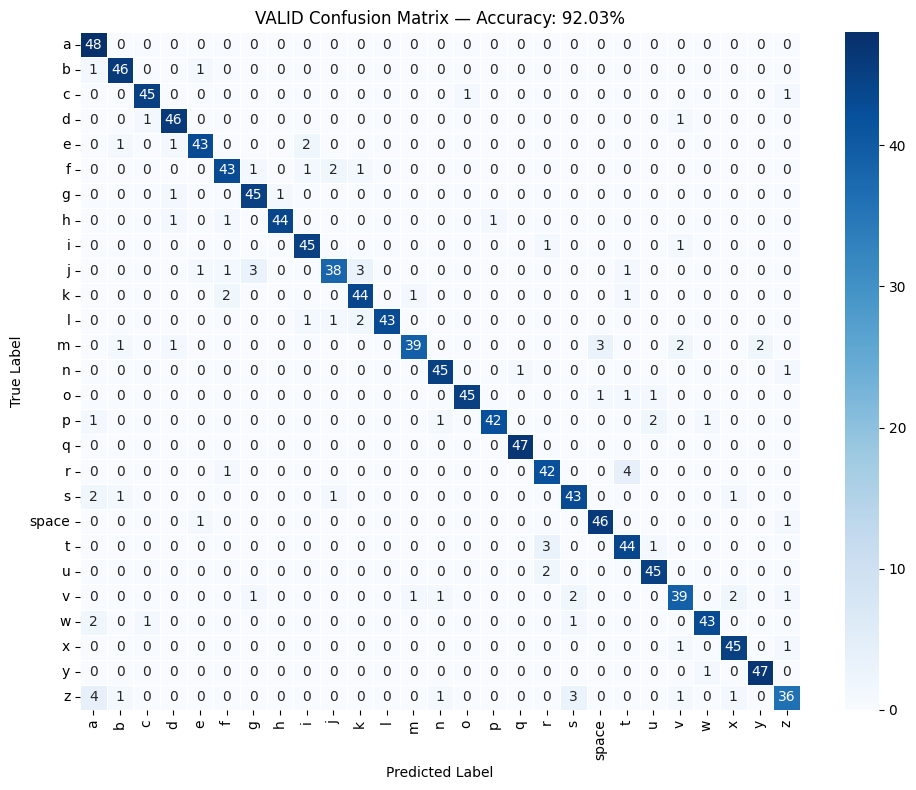


===== TEST RESULTS =====
Accuracy: 90.62%

Classification Report:
              precision    recall  f1-score   support

           a       0.86      0.92      0.89        59
           b       0.84      0.98      0.91        59
           c       0.93      0.97      0.95        59
           d       0.90      0.88      0.89        59
           e       0.89      0.92      0.90        59
           f       0.91      0.88      0.90        59
           g       0.80      0.90      0.85        59
           h       0.93      0.90      0.91        59
           i       0.92      0.98      0.95        60
           j       0.89      0.80      0.84        59
           k       0.92      0.95      0.93        59
           l       1.00      0.97      0.98        59
           m       0.91      0.86      0.89        59
           n       0.90      0.90      0.90        59
           o       0.95      0.98      0.97        59
           p       0.92      0.95      0.93        59
           q  

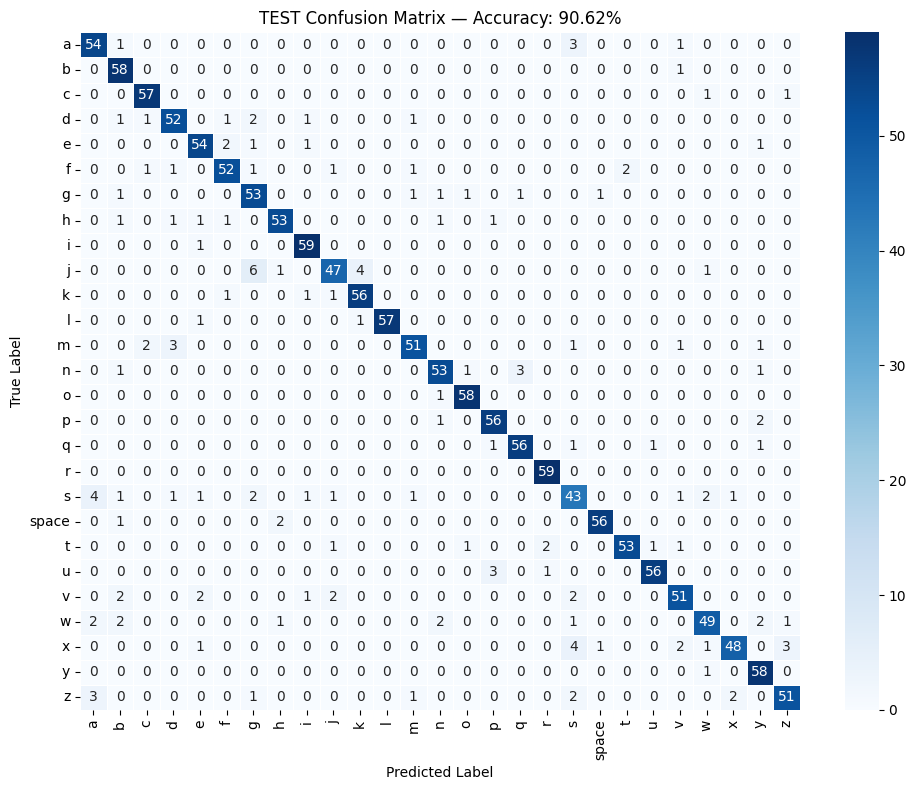

In [ ]:
def evaluate_model(model, X_data, y_true, split_name):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n===== {split_name} RESULTS =====")
    print(f"Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.5
    )
    plt.title(f'{split_name} Confusion Matrix — Accuracy: {acc*100:.2f}%')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return acc

valid_acc = evaluate_model(rf, X_valid, y_valid, 'VALID')
test_acc  = evaluate_model(rf, X_test,  y_test,  'TEST')

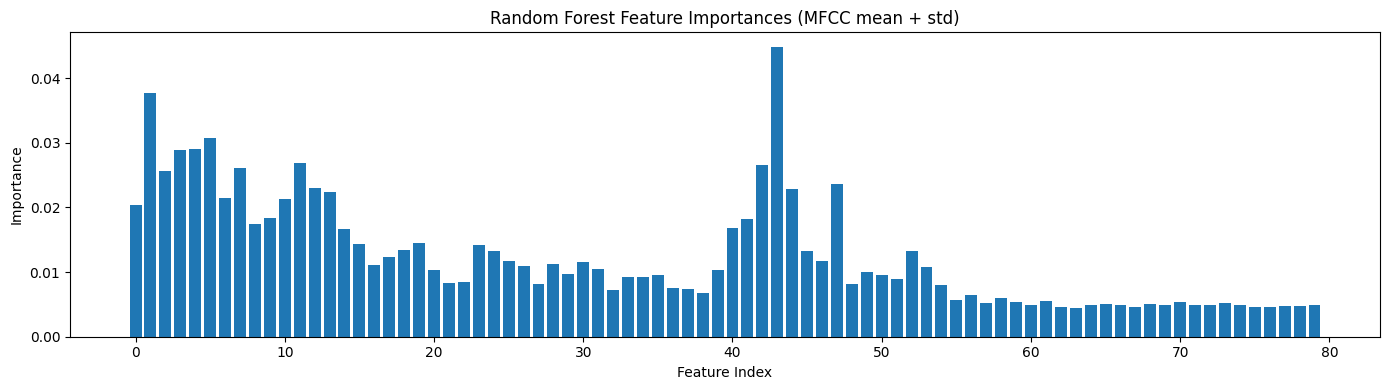

In [ ]:
importances = rf.feature_importances_

plt.figure(figsize=(14, 4))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest Feature Importances (MFCC mean + std)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/rf_keystroke_baseline_clean.pkl'

joblib.dump({
    'model': rf,
    'label_encoder': le,
    'scaler': scaler,
    'config': {
        'sample_rate': SAMPLE_RATE,
        'duration': DURATION,
        'n_mfcc': N_MFCC,
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH
    }
}, SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/rf_keystroke_baseline_clean.pkl
